# [Theme 21] 실전 딥러닝 파이프라인: 고성능 모델 튜닝 및 서빙 기초

7주차의 마지막 세션입니다. 오늘은 전이 학습 모델을 실제 환경에서 사용할 수 있도록 최적화하고, 추론(Inference) 파이프라인을 구축하는 실습을 진행합니다.

## 실습 순서
1. **Environment Setup**: 필요한 라이브러리 로드 및 디바이스 설정
2. **Advanced Optimization**: Cosine Annealing 및 Early Stopping 적용
3. **Model Serialization**: 학습된 모델의 저장 및 로드
4. **Inference Pipeline**: 새로운 이미지에 대한 결과 출력

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torchvision.transforms import ToTensor
from torch.optim import lr_scheduler, Adam
from torchvision.datasets import ImageFolder
from torchvision.models import vgg16, VGG16_Weights, resnet34, ResNet34_Weights
from torch.utils.data import Dataset, DataLoader, TensorDataset, Subset
from torchsummary import summary
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from PIL import Image
import cv2
import easyocr

from config import CONTENT_DIR

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams['font.family'] = 'NanumGothic' # Windows
# plt.rcParams['font.family'] = 'AppleGothic' # Mac
plt.rcParams['axes.unicode_minus'] = False

# 시드 고정
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

torch.set_printoptions(linewidth=1000)
set_seed(2026)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [2]:
img = cv2.imread(f'{CONTENT_DIR}/example_img1.png', cv2.IMREAD_UNCHANGED)
print("이미지 크기", img.shape)
print("이미지 유형", img.dtype)
print("이미지 차원", img.ndim)
print("이미지 사이즈", img.size)
print("이미지의 컬러 최소값", img.min())
print("이미지의 컬러 최대값", img.max())

이미지 크기 (640, 1024, 3)
이미지 유형 uint8
이미지 차원 3
이미지 사이즈 1966080
이미지의 컬러 최소값 0
이미지의 컬러 최대값 255


In [3]:
img = cv2.imread(f'{CONTENT_DIR}/business-card_640.jpg')
print(img.shape)

# 출력할 이미지 크기 설정(변환 후 크기)
w, h = 720, 480

srcQuad = np.array([[160, 207], [395, 112], [487, 221], [239, 327]], np.float32)
dstQuad = np.array([[0, 0], [w-1, 0], [w-1, h-1], [0, h-1]], np.float32)

pers = cv2.getPerspectiveTransform(srcQuad, dstQuad)
result = cv2.warpPerspective(img, pers, (w, h))

cv2.imshow('img', result)
cv2.waitKey(0)
cv2.destroyAllWindows()

(427, 640, 3)


QFontDatabase: Cannot find font directory /home/hong/project/ai-camp-note/.venv/lib/python3.13/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/hong/project/ai-camp-note/.venv/lib/python3.13/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/hong/project/ai-camp-note/.venv/lib/python3.13/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/hong/project/ai-camp-note/.venv/lib/python3.13/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabas

In [4]:
img = cv2.imread(f'{CONTENT_DIR}/example_img1.png')
print(img.shape)

x, y, w, h = 250, 250, 200, 200

# 사각형 그리기
cv2.rectangle(img, (x, y), (x+w, y+h), (0, 0, 255), 2)

# 원그리기 - 중심점, 크기
cv2.circle(img, (700, 200), 50, (255, 0, 0), 3)

# 텍스트그리기 - 영어만 됩니다. cv2
cv2.putText(img, "hello friends!", (50, 600), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)


cv2.imshow('img', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

(640, 1024, 3)


In [9]:
drawing = False # 마우스가 클릭이 된 상태인지 확인하는 변수
ix, iy = -1, -1
ex, ey = -1, -1

# 마우스 콜백 함수
def draw_rectangle(event, x, y, flags, param):
    global ix, iy, drawing, ex, ey

    if event == cv2.EVENT_LBUTTONDOWN:
        drawing = True
        ix, iy = x, y

    elif event == cv2.EVENT_MOUSEMOVE:
        if drawing:
            ex, ey = x, y
    elif event == cv2.EVENT_LBUTTONUP:
        drawing = False
        ex, ey = x, y
        cv2.rectangle(img, (ix, iy), (ex, ey), (0, 0, 255), 2)
img = cv2.imread(f'{CONTENT_DIR}/example_img1.png')
cv2.namedWindow('image')
cv2.setMouseCallback("image", draw_rectangle)


while True:
    try:
        cv2.imshow('image', img)
        key = cv2.waitKey(1)

        # q를 누르면 반복 종료
        if key == ord('q'):
            cv2.destroyAllWindows()
            break
    except:
        cv2.destroyAllWindows()
        break

In [5]:
points = [] # 클릭한 점들을 저장할 리스트

# 마우스 콜백 함수 - 클릭 순서는 왼쪽상단부터 시계방향으로 클릭
def click_event(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN and len(points) < 4: # 4개 미만의 점을 클릭한 경우
        points.append((x, y))
        cv2.circle(img, (x, y), 5, (0, 255, 0), -1) # 클릭한 위치에 초록색 원을 그림
        cv2.putText(img, f"{len(points)}", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2, cv2.LINE_AA)
        cv2.imshow('Image', img)

        if len(points) == 4: # 4개의 점이 선택되었을 때
            warp_perspective()

def warp_perspective():
    # 변환될 이미지의 가로와 세로 크기를 정합니다.
    w, h = 300, 200
    src = np.float32(points) # 원본 이미지에서 4개의 점
    dst = np.float32([[0, 0], [w, 0], [w, h], [0, h]]) # 목적지 이미지에서 4개의 점

    # 원근 변환 행렬 계산
    matrix = cv2.getPerspectiveTransform(src, dst)
    # 원근 변환 적용
    result = cv2.warpPerspective(img, matrix, (w, h))

    cv2.imshow('Perspective Transformation', result)

# 이미지를 불러오기
img = cv2.imread(CONTENT_DIR / 'business-card_640.jpg') # 'business-card_640.jpg'를 사용자의 이미지 경로로 변경
cv2.imshow('Image', img)
cv2.setMouseCallback('Image', click_event)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
img = cv2.imread(CONTENT_DIR / 'example_img1.png')

# ROI 선택지정
rc = cv2.selectROI("Select ROI", img)
cv2.destroyAllWindows()

x, y, w, h = rc

roi_img = img[y:y+h, x:x+w]

cv2.imshow("ROI image show", roi_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

Select a ROI and then press SPACE or ENTER button!
Cancel the selection process by pressing c button!


In [ ]:
img = cv2.imread(CONTENT_DIR / 'example_img1.png')
# 단순 블러 이미지
# 작은 노이즈를 줄이고 전체적으로 부드럽게 만들 때 사용
blurred_img = cv2.blur(img, (3,3)) # (5,5)는 5x5 영역을 의미. 각 픽셀 주변의 5x5 픽셀 평균을 내서 현재 픽셀값으로 바꿔줌.

# 가우시안 블러 : 중심 픽셀에 더 큰 가중치를 주는 블러
# 인물 사진 보정이나 노이즈 제어에 자주 사용
gaussian_blurred_img = cv2.GaussianBlur(img, (5,5), 0)

# 샤프닝 필터 : 주변 픽셀과의 차이를 강조해 경계가 선명해 보이게 함.
kernel = np.array(([0, -1, 0],
                   [-1, 5, -1],
                   [0, -1, 0]))

# filter2D : 사용자가 직접 만든 커널로 컨볼루션 연산을 수행
# cv2.filter2D(원본이미지, 출력이미지깊이)
sharpened_img = cv2.filter2D(img, -1, kernel=kernel)

cv2.imshow("original", img)
cv2.imshow("blurred_img", blurred_img)
cv2.imshow("gaussian_blurred_img", gaussian_blurred_img)
# cv2.imshow("sharpened_img", sharpened_img)

cv2.waitKey(0)
cv2.destroyAllWindows()

In [2]:
img = cv2.imread(CONTENT_DIR / 'kakao_13.jpg', cv2.IMREAD_GRAYSCALE)

# canny 엣지 검출
edges_canny = cv2.Canny(img, 100, 200)

# Sobel 엣지
edges_sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=5)
edges_sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=5)
edges_sobel = cv2.magnitude(edges_sobel_x, edges_sobel_y)

# Sobel 결과를 8비트로 변화
edges_sobel = cv2.convertScaleAbs(edges_sobel)

edges_canny_resized = cv2.resize(edges_canny, (600, 400))  # 600x400 크기로 조절
edges_sobel_resized = cv2.resize(edges_sobel, (600, 400))

cv2.imshow("edges_canny", edges_canny_resized)
cv2.imshow("edges_sobel", edges_sobel_resized)

# cv2.imshow("edges_canny", edges_canny)
# cv2.imshow("edges_sobel", edges_sobel)

cv2.waitKey(0)
cv2.destroyAllWindows()

QFontDatabase: Cannot find font directory /home/hong/project/ai-camp-note/.venv/lib/python3.13/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/hong/project/ai-camp-note/.venv/lib/python3.13/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/hong/project/ai-camp-note/.venv/lib/python3.13/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/hong/project/ai-camp-note/.venv/lib/python3.13/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabas

In [3]:
# OpenCV 이미지 여러 개를 Matplotlib을 이용해 한번에 출력하는 함수
def im_show(*opencv_images):
    img_number = len(opencv_images)
    plt.figure(figsize=(4*img_number,4))
    for idx, img in enumerate(opencv_images):
        plt.subplot(1, img_number, idx+1)

        # 그레이스케일 이미지 처리
        if len(img.shape) == 2:
            # 그레이스케일 이미지
            plt.imshow(img, cmap='gray')
        else:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.imshow(img_rgb)
        # plt.axis('off')  # 축 표시 제거
    plt.show()

(640, 1024, 3)


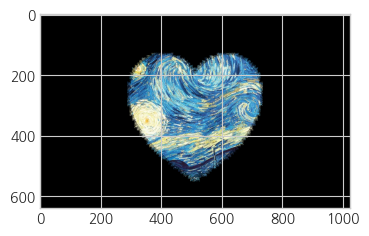

In [ ]:
# 원본 이미지 로드
original_img = cv2.imread(CONTENT_DIR / 'example_img1.png')

# 마스크 이미지 로드 (원본 이미지와 같은 크기, 흑백 이미지)
mask = cv2.imread(CONTENT_DIR / 'mask_heart.jpg', cv2.IMREAD_GRAYSCALE)
mask2 = cv2.bitwise_not(mask)

# 마스크 이미지를 이용해서 특정 부분만 보존
# 추가 이미지
image2 = cv2.imread(CONTENT_DIR / 'kakao_13.jpg')
image2 = cv2.resize(image2, (1024, 640), interpolation=cv2.INTER_AREA)
print(image2.shape)
masked_img = cv2.bitwise_and(original_img, original_img, mask=mask)
masked_img2 = cv2.bitwise_and(image2, image2, mask=mask2)

# # 최종 결과 이미지 표시
cv2.imshow('masked_img', masked_img)
cv2.imshow('masked_img2', masked_img2)
cv2.waitKey(0)
cv2.destroyAllWindows()

# matplotlib 로 출력하기
im_show(masked_img)

In [10]:
# 원본 이미지 로드
original_img = cv2.imread(CONTENT_DIR / 'example_img1.png')
print(original_img.shape)
# 알파 채널 이미지 로드
# IMREAD_UNCHANGED를 사용하면 PNG의 알파 채널까지 그대로 읽음
mask = cv2.imread(CONTENT_DIR / 'cat_face.png', cv2.IMREAD_UNCHANGED)
print(mask.shape)

# split으로 4개 채널을 분리, 이 중 알파 채널만 마스크로 사용.
_, _, _, alpha_channel = cv2.split(mask)

h, w = original_img.shape[:2]
resized_mask = cv2.resize(alpha_channel, (w, h), interpolation=cv2.INTER_AREA)
masked_img = cv2.bitwise_and(original_img, original_img, mask=resized_mask)

cv2.imshow("masked_img", masked_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

(640, 1024, 3)
(500, 500, 4)


In [7]:
target_img = original_img[320-250:320+250, 512-250:512+250]

cv2.imshow("target_img", target_img)
cv2.imshow("original_img", original_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [9]:
# 대상 이미지(target_img)와 같은 크기로 알파 채널을 조정하여 적용해야 함
alpha_channel_resized = cv2.resize(alpha_channel, (target_img.shape[1], target_img.shape[0]), interpolation=cv2.INTER_AREA)
# 크기를 맞춘 알파 채널을 마스크로 사용해 target_img의 원하는 부분만 남김.
masked_img_target = cv2.bitwise_and(target_img, target_img, mask=alpha_channel_resized)

cv2.imshow("masked_img_target", masked_img_target)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [12]:
# 이미지 읽기
img = cv2.imread(CONTENT_DIR / 'example_img1.png')

# 대부분의 특징점 검출 알고리즘은 밝기 변화가 핵심. 
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Harris Corner Detection
gray = np.float32(gray)
dst = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)  # K : 해리스 감도 계수(0.04~0.06)

dst = cv2.dilate(dst, None)

# 임계값을 초과하는 코너에 색상 표시
img[dst > 0.01 * dst.max()] = [0,0, 255]  # 검출된 코너를 빨간색으로 표시

# 결과 출력
cv2.imshow('Harris Corners', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [14]:
# 이미지 읽기
img = cv2.imread(CONTENT_DIR / 'example_img1.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# SIFT 생성
sift = cv2.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(gray, None)

# 키포인트를 이미지에 그리기
img_sift = cv2.drawKeypoints(img, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

cv2.imshow('SIFT Keypoints', img_sift)
cv2.waitKey(0)
cv2.destroyAllWindows()

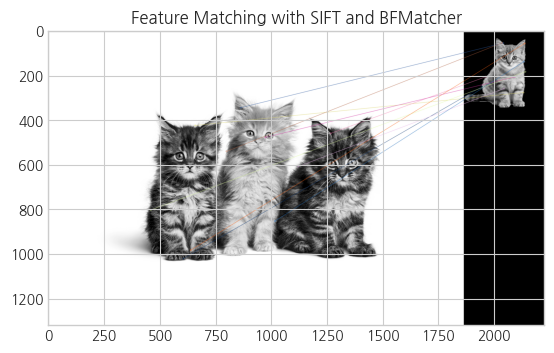

In [15]:
# 이미지 파일 경로 설정
image_path1 = CONTENT_DIR / 'cat1.png'
image_path2 = CONTENT_DIR / 'cat_test.png'

# 이미지 읽기
img1 = cv2.imread(image_path1, cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread(image_path2, cv2.IMREAD_GRAYSCALE)
if img1 is None or img2 is None:
    raise ValueError("Error: Could not open or find the images")

# SIFT 특징점 검출
sift = cv2.SIFT_create()
keypoints1, descriptors1 = sift.detectAndCompute(img1, None)
keypoints2, descriptors2 = sift.detectAndCompute(img2, None)

# Brute-Force 매칭기 생성 및 매칭
# crossCheck=True 
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches = bf.match(descriptors1, descriptors2)
matches = sorted(matches, key=lambda x: x.distance)

# 매칭 결과 이미지 그리기
img_matches = cv2.drawMatches(img1, keypoints1, img2, keypoints2, matches[:10], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.imshow(img_matches)
plt.title('Feature Matching with SIFT and BFMatcher')
plt.show()

In [17]:
cap = cv2.VideoCapture(CONTENT_DIR / 'cat_video.mp4')

print("영상의 가로 크기", int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)))
print("영상의 세로 크기", int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))
print("영상의 프레임수", int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))
print("영상의 프레임 속도", int(cap.get(cv2.CAP_PROP_FPS)))

while True:
    # ret : 프레임 읽기 성공 여부
    # frame : 실제 프레임 이미지 데이터. NumPy 배열.
    ret, frame = cap.read()

    # 더 이상 읽을 프레임이 없거나 오류가 나면 반복을 중단
    if not ret:
        break

    # 읽은 프레임을 OpenCV 창에 표시
    cv2.imshow('frame', frame)

    # q 입력하면 종료
    if cv2.waitKey(1) == ord('q'):
        break
 
cap.release()
cv2.destroyAllWindows()

영상의 가로 크기 1920
영상의 세로 크기 1080
영상의 프레임수 1515
영상의 프레임 속도 25


In [20]:
# 0번 장치를 기본 웹캠으로 엽니다.
cap = cv2.VideoCapture(CONTENT_DIR / 'cat_video.mp4')

while True:
    ret, frame = cap.read()
    if not ret:
        break
    # 프레임을 표시
    else:
        frame = cv2.flip(frame, 1)

        face = frame[100:300, 200:400]
        face_resized = cv2.resize(face, (10,10), interpolation=cv2.INTER_AREA)

        face_resized = cv2.resize(face_resized, (200, 200), interpolation=cv2.INTER_AREA)

        frame[100:300, 200:400] = face_resized

        cv2.imshow("frame", face_resized)

        if cv2.waitKey(1) == ord('q'):
            break
cap.release()
cv2.destroyAllWindows()

In [22]:
cap = cv2.VideoCapture(CONTENT_DIR / 'cat_video.mp4')
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
# 비디오 저장을 위한 videowriter 객체 설정
# fourcc = cv2.VideoWriter_fourcc(*'MP4V')
fourcc = cv2.VideoWriter_fourcc(*'X264')
out = cv2.VideoWriter('gray_cat.mp4', fourcc, fps, (frame_width, frame_height), False)

while True:
    ret, frame = cap.read()
    if not ret:
        break
    # 프레임을 표시
    else:
        # 흑백으로 바꾸기
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        out.write(frame)
        
        cv2.imshow("frame", frame)
        if cv2.waitKey(1) == ord('q'):
            break
cap.release()
# out.release()
cv2.destroyAllWindows()

OpenCV: FFMPEG: tag 0x34363258/'X264' is not supported with codec id 27 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x31637661/'avc1'
[h264_v4l2m2m @ 0x3f87c780] Could not find a valid device
[h264_v4l2m2m @ 0x3f87c780] can't configure encoder
[ERROR:0@11821.435] global cap_ffmpeg_impl.hpp:3514 open Could not open codec h264_v4l2m2m, error: Unspecified error (-22)
[ERROR:0@11821.435] global cap_ffmpeg_impl.hpp:3531 open VIDEOIO/FFMPEG: Failed to initialize VideoWriter


In [27]:
cascade_path = cv2.data.haarcascades + 'haarcascade_frontalcatface_extended.xml'

# Haar Cascade 로드
face_cascade = cv2.CascadeClassifier(cascade_path)

# 웹캠 열기
cap = cv2.VideoCapture(CONTENT_DIR / 'cat_video.mp4')

if not cap.isOpened():
    print("웹캠이 연결이 안됩니다")

while True:

    # 프레임 읽기
    ret, frame = cap.read()

    if not ret:
        break

    # 그레이스케일 - 흑백 변환
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # 얼굴 검출
    faces = face_cascade.detectMultiScale(
        gray_frame,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(300,300))

    for x, y, w, h in faces:
        cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 0, 0), 2)

    # 출력
    cv2.imshow("frame", frame)
    if cv2.waitKey(1) == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

In [ ]:
# 넣을 이모티콘 이미지 로드
emoji_img = cv2.imread(CONTENT_DIR / 'gnd.png')

# 웹캠 열기
cap = cv2.VideoCapture(CONTENT_DIR / 'cat_video.mp4')

if not cap.isOpened():
    print("웹캠이 연결이 안됩니다")

while True:

    # 프레임 읽기
    ret, frame = cap.read()

    if not ret:
        break

    # 그레이스케일 - 흑백 변환
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # 얼굴 검출
    faces = face_cascade.detectMultiScale(
        gray_frame,
         scaleFactor=1.1, 
        
        minNeighbors=5,
         minSize=(30,30))

    for i in faces:
         # 검출된 얼굴 크기에 맞게 합성 이미지를 조정
        emoji_img_resized = cv2.resize(emoji_img, (w, h))

        # 얼굴 영역을 합성 이미지로 그대로 교체
        frame[y:y + h, x:x + w] = emoji_img_resized

    # 출력
    cv2.imshow("frame", frame)
    if cv2.waitKey(1) == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

In [33]:
# 넣을 이모티콘 이미지 로드
emoji_img = cv2.imread(CONTENT_DIR / 'cat_face.png', cv2.IMREAD_UNCHANGED)
print(emoji_img.shape)

emoji_alpha = emoji_img[:, :, 3] / 255.0
emoji_bgr = emoji_img[:, :, :3] # brg 채널값

# 웹캠 열기
cap = cv2.VideoCapture(CONTENT_DIR / 'cat_video.mp4')

if not cap.isOpened():
    print("웹캠이 연결이 안됩니다")

while True:

    # 프레임 읽기
    ret, frame = cap.read()

    if not ret:
        break

    # # 그레이스케일 - 흑백 변환
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # # 얼굴 검출
    faces = face_cascade.detectMultiScale(gray_frame, scaleFactor=1.1, minNeighbors=5, minSize=(30,30))

    for i in faces:
        x, y, w, h = i

        # 넣을 이미지 크기 조정
        emoji_img_resized = cv2.resize(emoji_bgr, (w, h))

        # 알파 채널도 이미지 크기 조정
        emoji_alpha_resized = cv2.resize(emoji_alpha, (w, h))

        # 얼굴 부위 추출
        face_part = frame[y:y+h, x:x+w]

        # 배경(얼굴 부위) 반대 마스크
        background_alpha = 1.0 - emoji_alpha_resized

        # 마스크 이미지의 알파 채널과 RGB 채널을 곱해서 마스크 이미지에서 알파 처리된 부분을 추출
        alpha_face = emoji_alpha_resized[..., np.newaxis] * emoji_img_resized

        # 원본 이미지의 해당 영역과 배경 알파 채널을 곱해서 배경 추출
        background_face = background_alpha[..., np.newaxis] * face_part

        # 최종 추출된 두 부분을 합쳐서 얼굴 부분을 생성
        face_part = alpha_face + background_face

        frame[y:y+h, x:x+w] = face_part
    # 출력
    cv2.imshow("frame", frame)
    if cv2.waitKey(1) == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

(500, 500, 4)


In [2]:
image = cv2.imread(CONTENT_DIR / 'en_sample.jpg')
reader = easyocr.Reader(['en'], detect_network='craft', gpu=False)

gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
results= reader.detect(gray_image)

Using CPU. Note: This module is much faster with a GPU.


In [ ]:
# 텍스트 영역 바운딩 박스 그리기
easyocr_result = image.copy()

# 1. 수평 박스 처리
for bbox_group in results[0]:
    for bbox in bbox_group:
        # np.int32 타입을 일반 int로 안전하게 변환
        x1, x2, y1, y2 = map(int, bbox) 
        tl = (x1, y1)
        br = (x2, y2)
        cv2.rectangle(easyocr_result, tl, br, (0, 255, 0), 2)

# 2. 자유 형태 박스 처리
for bbox_group in results[1]:
    for bbox in bbox_group:
        x_coords = [int(point[0]) for point in bbox]
        y_coords = [int(point[1]) for point in bbox]
        tl = (min(x_coords), min(y_coords))
        br = (max(x_coords), max(y_coords))
        cv2.rectangle(easyocr_result, tl, br, (255, 0, 0), 2)

# cv2.imwrite('ocr_result.jpg', easyocr_result)


error: OpenCV(4.13.0) /io/opencv/modules/highgui/src/window.cpp:1301: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvShowImage'


In [5]:
import PIL
PIL.Image.ANTIALIAS = PIL.Image.LANCZOS
results = reader.readtext(f'{CONTENT_DIR}/en_sample.jpg')

# easyocr 결과가 results 변수에 들어있다고 가정
texts = [text for (_, text, _) in results]

print("추출된 텍스트:")
for t in texts:
    print(t)

# 결과 출력
for bbox, text, prob in results:
    print(f"인식된 텍스트: {text} (신뢰도: {prob:.2f})")

/home/hong/project/ai-camp-note/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


추출된 텍스트:
MORGAN
MAXWELL
General Manager
+123-456-7890
hello@reallygreatsite.com
Liceria & Co_
wwW.reallygreatsite.com
Real Estate
123 Anywhere
City, ST 12345
St,
Any
인식된 텍스트: MORGAN (신뢰도: 1.00)
인식된 텍스트: MAXWELL (신뢰도: 1.00)
인식된 텍스트: General Manager (신뢰도: 1.00)
인식된 텍스트: +123-456-7890 (신뢰도: 0.79)
인식된 텍스트: hello@reallygreatsite.com (신뢰도: 0.77)
인식된 텍스트: Liceria & Co_ (신뢰도: 0.88)
인식된 텍스트: wwW.reallygreatsite.com (신뢰도: 0.70)
인식된 텍스트: Real Estate (신뢰도: 0.84)
인식된 텍스트: 123 Anywhere (신뢰도: 0.99)
인식된 텍스트: City, ST 12345 (신뢰도: 0.97)
인식된 텍스트: St, (신뢰도: 0.88)
인식된 텍스트: Any (신뢰도: 1.00)


In [8]:
import pytesseract
import csv
from io import  StringIO

# image_to_data는 OCR 결과를 TSV(tab-separated values) 문자열로 반환
text = pytesseract.image_to_data(gray_image, lang='eng')

def parse_text_to_dict(text):
    # StringIO 객체를 사용하여 문자열을 파일처럼 처리
    csv_file = StringIO(text)

    # csv.DictReader를 사용하여 CSV 형식의 데이터를 읽음
    reader = csv.DictReader(csv_file, delimiter="\t")

    # 결과를 저장할 리스트
    result = []

    # 각 행을 순회하며 딕셔너리로 변환
    for row in reader:
        # 모든 키-값 쌍을 순회하며 값을 적절한 타입으로 변환
        parsed_row = {}
        for key, value in row.items():
            if key in ["level", "page_num", "block_num", "par_num", "line_num", "word_num"]:
                parsed_row[key] = int(value)
            elif key in ["left", "top", "width", "height"]:
                parsed_row[key] = int(value)
            elif key == "conf":
                parsed_row[key] = int(value) if value != "-1" else -1
            else:
                parsed_row[key] = value

        result.append(parsed_row)

    return result

parsed_data = parse_text_to_dict(text)

texts = [item['text'] for item in parsed_data if item['text'].strip() != '']

print("추출된 텍스트:")
for t in texts:
    print(t)

# 텍스트 영역 바운딩 박스 그리기
tesseract_result = image.copy()
for item in parsed_data:
    text = item["text"]

    if text == "":
        continue

    # 바운딩 박스 좌표 추출
    left = item["left"]
    top = item["top"]
    width = item["width"]
    height = item["height"]

    # 바운딩 박스의 좌상단과 우하단 좌표 계산
    tl = (left, top)
    br = (left + width, top + height)

    # 바운딩 박스 그리기
    cv2.rectangle(tesseract_result, tl, br, (0, 255, 0), 2)

추출된 텍스트:
Liceria
&
Co.
Real
Estate
MORGAN
MAXWELL
General
Manager
&
+123-456-7890
=
hello@reallygreatsite.com
®
www.reallygreatsite.com
f
123
Anywhere
St.,
Any
City,
ST
12345


# 작업 순서

1. api를 호출할 클래스 구현
    - 일별 박스 오피스 (상위 10개)
    - 영화목록
    - 영화 상세정보
    - 영화사 목록
    - 영화사 상세정보
    - 영화인 목록
    - 영화인 상세정보
    - 공휴일, 문화의 날 행사 데이터
2. daily_boxoffice > Movies, daily_market > 그 외 테이블 순으로 적재
    - 의존을 낮추기 위해 movie_id는 외래키로 사용하지 않음
3. db > feature csv 저장